In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/retrieval_evaluation_results.csv")
df.head()

,embedding_model,chunk_size,use_metadata_filter,avg_precision,avg_recall,avg_f1_score
0,sentence-transformers/all-MiniLM-L6-v2,800,True,0.984563,1.000000,0.990899
1,sentence-transformers/all-MiniLM-L6-v2,800,False,0.073302,0.138730,0.095807
2,sentence-transformers/all-MiniLM-L6-v2,289,True,0.982895,0.790032,0.869289
3,sentence-transformers/all-MiniLM-L6-v2,289,False,0.074476,0.129703,0.094130
4,sentence-transformers/all-MiniLM-L6-v2,137,True,0.979470,0.392071,0.554591


In [4]:
avg_precsion_df = df.groupby(["embedding_model", "chunk_size", "use_metadata_filter"])["avg_precision"].mean().reset_index()
avg_recall_df = df.groupby(["embedding_model", "chunk_size", "use_metadata_filter"])["avg_recall"].mean().reset_index()
avg_f1_df = df.groupby(["embedding_model", "chunk_size", "use_metadata_filter"])["avg_f1_score"].mean().reset_index()

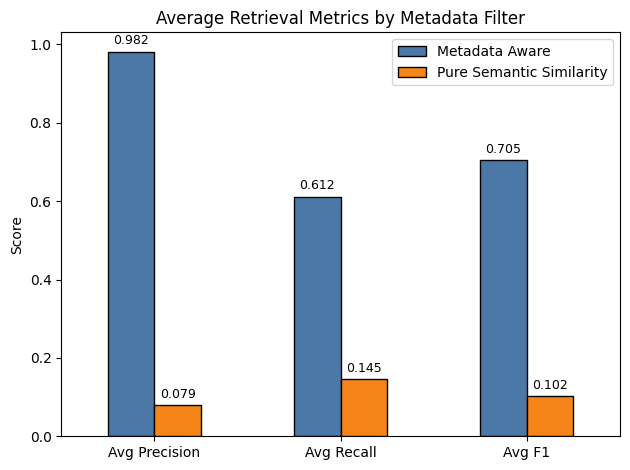

In [28]:
#1) Average metrics by metadata flag

agg = (
    df.groupby("use_metadata_filter")[["avg_precision", "avg_recall", "avg_f1_score"]]
    .mean()
    .rename(index={True: "Metadata Aware", False: "Pure Semantic Similarity"})
)

metric_labels = {
        "avg_precision": "Avg Precision",
        "avg_recall": "Avg Recall",
        "avg_f1_score": "Avg F1"
    }
agg.rename(columns=metric_labels, inplace=True)

# 2) Reorder so False is bottom stack, True is top stack
agg = agg.reindex(["Metadata Aware", "Pure Semantic Similarity"])

# 3) Prepare for stacked plot:
#    rows = metrics, columns = metadata flags
plot_df = agg.T

ax = plot_df.plot(
    kind="bar",
    stacked=False,
    # figsize=(5, 8),
    color=["#4C78A8", "#F58518"],
    edgecolor="black"
)
ax.set_title("Average Retrieval Metrics by Metadata Filter")
# ax.set_xlabel("Metric")
ax.set_ylabel("Score")
# ax.set_ylim(0, 1)
plt.xticks(rotation=0)
ax.legend( loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)


plt.tight_layout()
plt.show()

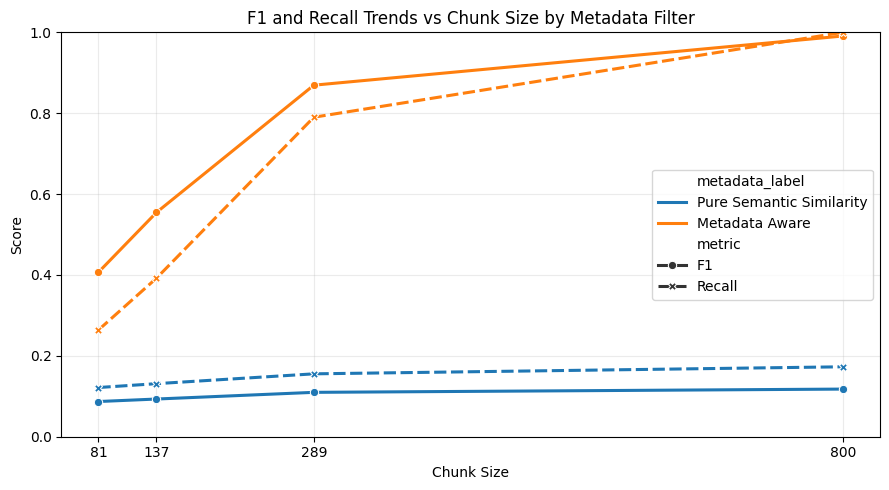

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Make a copy and clean types
# df = results.copy()
# df["chunk_size"] = pd.to_numeric(df["chunk_size"], errors="coerce")
# df["avg_f1_score"] = pd.to_numeric(df["avg_f1_score"], errors="coerce")
# df = df.dropna(subset=["chunk_size", "avg_f1_score", "use_metadata_filter"])

# If you want one trend line per metadata setting (averaged across all embeddings)
# Average across embeddings for each chunk size + metadata setting
trend = (
    df.groupby(["chunk_size", "use_metadata_filter"], as_index=False)[["avg_f1_score", "avg_recall"]]
      .mean()
      .sort_values("chunk_size")
)

trend["metadata_label"] = trend["use_metadata_filter"].map({
    True: "Metadata Aware",
    False: "Pure Semantic Similarity"
})

# Convert to long format so we can draw both metrics
trend_long = trend.melt(
    id_vars=["chunk_size", "metadata_label"],
    value_vars=["avg_f1_score", "avg_recall"],
    var_name="metric",
    value_name="score"
)

trend_long["metric"] = trend_long["metric"].map({
    "avg_f1_score": "F1",
    "avg_recall": "Recall"
})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=trend_long,
    x="chunk_size",
    y="score",
    hue="metadata_label",
    style="metric",      # separate line style for F1 vs Recall
    markers=True,
    dashes=True,
    linewidth=2.2
)

plt.title("F1 and Recall Trends vs Chunk Size by Metadata Filter")
plt.xlabel("Chunk Size")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(sorted(trend_long["chunk_size"].unique()))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

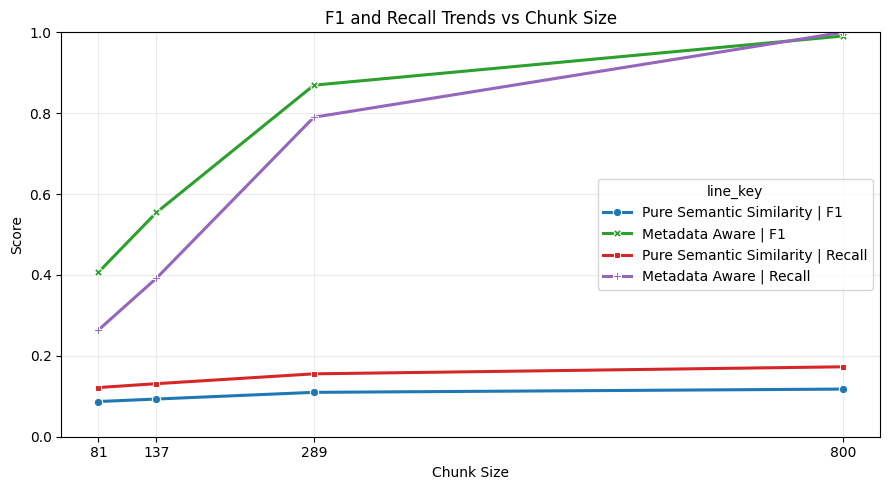

In [34]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=trend_long,
    x="chunk_size",
    y="score",
    hue="metadata_label",      # 2 groups
    style="metric",            # 2 groups
    markers=True,
    dashes=True,
    linewidth=2.2,
    palette=["#1f77b4", "#ff7f0e"],  # colors for hue groups
)

# If you want all 4 lines uniquely colored, combine labels first:
trend_long["line_key"] = trend_long["metadata_label"] + " | " + trend_long["metric"]

plt.clf()
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=trend_long,
    x="chunk_size",
    y="score",
    hue="line_key",
    style="line_key",
    markers=True,
    dashes=False,
    linewidth=2.2,
    palette=["#1f77b4", "#2ca02c", "#d62728", "#9467bd"],  # 4 distinct colors
)

plt.title("F1 and Recall Trends vs Chunk Size")
plt.xlabel("Chunk Size")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(sorted(trend_long["chunk_size"].unique()))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()